# Double Machine Learning DiD - When Covariate Adjustment Is Too Hard to Get Right by Hand

Staggered difference-in-differences with covariates rests on modeling two nuisance
functions: the probability of treatment given covariates (the propensity score) and the
untreated outcome trend given covariates. Callaway-Sant'Anna estimates both with fixed
parametric forms - logit and OLS. When the true relationships are nonlinear, those
models are misspecified and the "doubly robust" estimate quietly inherits the bias.

**DMLDiD** (Chang 2020) keeps the same cell architecture and aggregation surface as
Callaway-Sant'Anna but plugs *cross-fitted machine-learning learners* into the
nuisances. Neyman orthogonality makes the treatment-effect estimate first-order
insensitive to nuisance estimation error, and cross-fitting (each observation scored by
learners trained on the *other* folds) removes the own-observation overfitting that
would otherwise invalidate inference.

This tutorial:

1. Explains when to reach for DMLDiD instead of Callaway-Sant'Anna.
2. Builds a staggered panel with *nonlinear confounding* in both nuisances.
3. Runs the first fit and reads the provenance-rich `summary()`.
4. Compares outcome learners - and watches the misspecified linear model fail.
5. Reads the cross-fitting diagnostics.
6. Aggregates to event-study and group effects, runs HonestDiD, and adds
   bootstrap uniform bands.
7. Runs the repeated-cross-section lane (`panel=False`), with a survey design.
8. Shows what `seed=` does and does not pin.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import (
    DMLDiD,
    SurveyDesign,
    compute_honest_did,
    plot_event_study,
    practitioner_next_steps,
)

pd.set_option("display.precision", 4)


## 1. Why ML Nuisances - and Why Cross-Fitting

Chang's estimator targets the same cohort-period estimand and keeps the
Callaway-Sant'Anna cell architecture, but scores each `(cohort g, period t)` cell
with **Chang's own Neyman-orthogonal moment** - a distinct score family from the
Sant'Anna-Zhao doubly-robust score CS uses (Chang normalizes by the unconditional
treated share $\hat p_g$ and carries its associated augmentation term; the
repeated-cross-section case adds further $\lambda$-related terms). The two
plug-in nuisances

- $\hat g_{g}(X)$ - the conditional propensity of belonging to cohort $g$ given covariates, and
- $\hat\ell_{gt}(X) = E[\Delta Y \mid X, \text{control}]$ - the control outcome-change
  regression,

come from **cross-fitted learners**: the sample is split into $K$ folds, and each
observation's nuisance predictions come from learners trained on the other $K-1$
folds. Two properties carry the theory (Chang 2020, Thm. 1-2):

- **Neyman orthogonality** - the moment's derivative with respect to each nuisance is
  zero at the truth, so small nuisance errors have only second-order effect on the ATT;
- **sample splitting** - predictions never come from a learner that saw the
  observation, so flexible learners cannot overfit their own scores.

*When to prefer it over `CallawaySantAnna`*: covariate relationships that are
nonlinear or high-dimensional. When a logit + linear-OLS specification is plausible,
prefer CS - fewer moving parts, replicate-weight support, and no learner tuning (see
*Choosing an estimator* in the docs). DMLDiD **requires** covariates: without them the
learners have nothing to do, and `fit()` points you back to CS.


## 2. A Staggered Panel with Nonlinear Confounding

We build a 600-unit, 6-period panel with cohorts treated at $t=4$ and $t=5$ plus a
large never-treated pool, and we bury a *quadratic* confounder in both nuisances:

- **assignment**: treatment probability is an expit of $0.9(x_1^2 - 1) + 0.7 x_1 x_2$
  - so a logistic model in *raw* $(x_1, x_2)$ is misspecified;
- **trend**: untreated outcomes drift along $f(X)\, t/6$ with
  $f(X) = 1.6(x_1^2 - 1) + x_1 x_2$ - a covariate-dependent trend that survives
  differencing (levels difference out in DiD; only the trend confounds), and is
  nonlinear in exactly the way a linear outcome learner cannot absorb.

The true effect is dynamic and known by construction:
$\tau(e) = 2.0 + 0.3\,e$ at event time $e = t - g$.


In [2]:
rng = np.random.default_rng(7)
n_units, periods = 600, [1, 2, 3, 4, 5, 6]

x1 = rng.normal(size=n_units)
x2 = rng.normal(size=n_units)

# Assignment: expit of a QUADRATIC score -> logit-on-raw-X is misspecified.
# Capped at 0.60 so a large never-treated pool always survives (the default
# control_group="never_treated" needs one).
score = 0.9 * (x1**2 - 1.0) + 0.7 * x1 * x2
p_any = np.clip(1.0 / (1.0 + np.exp(-score)), 0.05, 0.60)
treated = rng.uniform(size=n_units) < p_any
early = rng.uniform(size=n_units) < 0.5
cohort = np.where(treated, np.where(early, 4, 5), 0)

# Untreated outcome: nonlinear covariate-dependent TREND (this is what
# confounds a DiD; time-invariant levels difference out).
f_nl = 1.6 * (x1**2 - 1.0) + 1.0 * x1 * x2
rows = []
for i in range(n_units):
    alpha_i = 0.5 * x1[i] - 0.3 * x2[i] + rng.normal(scale=0.3)
    for t in periods:
        y = 1.0 + 0.25 * t + alpha_i + f_nl[i] * (t / 6) + rng.normal(scale=0.5)
        if cohort[i] > 0 and t >= cohort[i]:
            y += 2.0 + 0.3 * (t - cohort[i])  # true tau(e) = 2.0 + 0.3 e
        rows.append((i, t, y, cohort[i], x1[i], x2[i]))
df = pd.DataFrame(rows, columns=["unit", "time", "y", "first_treat", "x1", "x2"])

df.groupby("unit")["first_treat"].first().value_counts().sort_index()


first_treat
0    354
4    121
5    125
Name: count, dtype: int64

354 never-treated units against cohorts of 121 ($g=4$) and 125 ($g=5$).

## 3. First Fit

The propensity learner has exactly one built-in spec (`"logit"`); the outcome learner
is where the flexibility lives - `"sieve"` is an adaptive polynomial whose degree is
selected by BIC per cell. `seed=` pins the fold draws, and
`base_period="universal"` benchmarks every pre-period against $t = g-1$ (the default
is `"varying"`; universal is what HonestDiD in section 6 needs).


In [3]:
fit_kw = dict(
    outcome="y", unit="unit", time="time", first_treat="first_treat",
    covariates=["x1", "x2"],
)

est = DMLDiD(
    propensity_learner="logit",   # the only built-in propensity spec
    outcome_learner="sieve",      # adaptive polynomial, BIC-selected degree
    n_folds=5,
    seed=42,                      # pins the fold draws
    base_period="universal",
)
res = est.fit(df, **fit_kw)
print(res.summary())


           DML DiD (Chang 2020) Staggered Difference-in-Differences Results          

Propensity learner:               'logit'
Outcome learner:                  'sieve'
Cross-fitting folds (K):                5
Seed:                                  42

Total observations:                  3600
Treated units:                        246
Never-treated units:                  354
Treatment cohorts:                      2
Time periods:                           6
Control group:                 never_treated
Base period:                    universal

-------------------------------------------------------------------------------------
                   Overall Average Treatment Effect on the Treated                   
-------------------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     z-stat      P>|z|   Sig.
-------------------------------------------------------------------------------------
ATT                   2.2804   

The header records the full nuisance provenance - learners, folds, seed - so a
serialized result is self-describing.

**What should this number be?** `overall_att` is the simple aggregation: an average of
the post-treatment cell effects $ATT(g,t)$ weighted by each cell's treated count. The
DGP knows every cell's true effect, so we can compute the exact target by applying
the *fit's own* aggregation weights to the true per-cell effects:


In [4]:
BASE, SLOPE = 2.0, 0.3
num = den = 0.0
for (g, t), cell in res.group_time_effects.items():
    if t < g or cell.get("is_reference"):
        continue  # overall_att averages post-treatment cells only
    w = cell["n_treated"]  # the fit's own per-cell aggregation weight
    num += w * (BASE + SLOPE * (t - g))
    den += w
true_att = num / den
print(f"DGP-implied overall ATT: {true_att:.4f}")
print(f"DMLDiD (sieve) estimate: {res.overall_att:.4f} +/- {res.overall_se:.4f}")


DGP-implied overall ATT: 2.2388
DMLDiD (sieve) estimate: 2.2804 +/- 0.0438


The sieve fit lands on **2.2804 ± 0.0438** against a true **2.2388** - within one
standard error.

## 4. Learner Comparison - Watching Misspecification Fail

Now the punchline. We refit with four outcome learners, keeping everything else
identical. One of them is a **custom learner object**: DMLDiD accepts any object with
`fit(X, y, sample_weight=None)` and `predict(X)` (classifiers: `predict_proba`).
Here is a numpy-only ridge regression on degree-2 polynomial features - flexible
enough to represent the DGP's quadratic trend:


In [5]:
class PolynomialRidge:
    """Degree-2 polynomial features + ridge normal equations (numpy only)."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def _expand(self, X):
        n, d = X.shape
        cols = [np.ones(n)] + [X[:, j] for j in range(d)]
        for j in range(d):
            for k in range(j, d):
                cols.append(X[:, j] * X[:, k])
        return np.column_stack(cols)

    def fit(self, X, y, sample_weight=None):
        Z = self._expand(np.asarray(X, dtype=np.float64))
        y = np.asarray(y, dtype=np.float64)
        w = np.ones(len(y)) if sample_weight is None else np.asarray(sample_weight, float)
        ZtW = Z.T * w
        A = ZtW @ Z + self.alpha * np.eye(Z.shape[1])
        A[0, 0] -= self.alpha  # leave the intercept unpenalized
        self.coef_ = np.linalg.solve(A, ZtW @ y)
        return self

    def predict(self, X):
        return self._expand(np.asarray(X, dtype=np.float64)) @ self.coef_


In [6]:
comparison = []
for name, learner in [
    ("linear", "linear"),
    ("ridge", "ridge"),
    ("sieve", "sieve"),
    ("PolynomialRidge (custom)", PolynomialRidge(alpha=1.0)),
]:
    r = DMLDiD(outcome_learner=learner, n_folds=5, seed=42,
               base_period="universal").fit(df, **fit_kw)
    comparison.append((name, r.overall_att, r.overall_se,
                       abs(r.overall_att - true_att) / r.overall_se))
pd.DataFrame(comparison, columns=["outcome learner", "ATT", "SE", "|bias| / SE"])


,outcome learner,ATT,SE,|bias| / SE
0,linear,2.5909,0.0743,4.7392
1,ridge,2.5898,0.0736,4.7720
2,sieve,2.2804,0.0438,0.9482
3,PolynomialRidge (custom),2.2818,0.0438,0.9823


Both misspecified learners miss high: **linear 2.5909** and **ridge 2.5898** sit
almost five standard errors above the true 2.2388 (a ridge penalty on the wrong
functional form is still the wrong functional form). The flexible learners recover
it: **sieve 2.2804** and the custom **PolynomialRidge 2.2818**, each within about
one standard error.

Why does fixing only the *outcome* learner rescue the estimate when the propensity
model (`"logit"` on raw $X$) is misspecified in **every** arm? That is **double
robustness** at work: Chang's moment is consistent when *either* nuisance is right,
and the flexible outcome learners get theirs right. Two honest caveats:

- Double robustness protects the *point estimate*. Chang's Theorem 1 inference needs
  **both** nuisances converging at $o(N^{-1/4})$ - "a fast learner cannot compensate
  a slow one" - so with a deliberately misspecified propensity, the SEs and CIs in
  this table are illustrative rather than theory-backed.
- Custom learner objects are **deep-copied, never-fit, once per fold**. A learner
  that cannot be deep-copied still runs, but with a loud `UserWarning`: the same
  instance is REUSED across folds relying on its fit-reset behavior, so a
  warm-start/stateful non-copyable learner can leak data across folds - make such
  a learner fully re-initialize on every `fit()`. Under `survey_design=`
  (section 7) the `sample_weight` keyword becomes mandatory, and stochastic
  learners need their own internal seeding (`seed=` pins folds, not your
  learner's RNG).


## 5. Cross-Fitting Diagnostics

Every fit records per-cell cross-fitting health in `cross_fit_diagnostics`: the
cell's treated share `p_hat`, the number of propensity scores clipped by the trim
(`pscore_trim=0.01` by default), and out-of-fold losses per fold (log-loss for the
propensity learner, MSE for the outcome learner).


In [7]:
diag_rows = []
for (g, t), d in sorted(res.cross_fit_diagnostics.items()):
    if "p_hat" not in d:
        continue  # universal-base reference cells carry no learner fits
    diag_rows.append((g, t, d["p_hat"], d["n_clipped_ps"],
                      np.nanmean(d["propensity"]["fold_losses"]),
                      np.nanmean(d["outcome"]["fold_losses"])))
pd.DataFrame(diag_rows, columns=[
    "g", "t", "p_hat", "n_clipped", "propensity log-loss", "outcome MSE"])


,g,t,p_hat,n_clipped,propensity log-loss,outcome MSE
0,4,1,0.2547,0,0.5767,0.5145
1,4,2,0.2547,0,0.5772,0.5026
2,4,4,0.2547,0,0.5764,1.6779
3,4,5,0.2547,0,0.5759,1.7839
4,4,6,0.2547,0,0.5780,2.3770
5,5,1,0.2610,0,0.5706,0.4929
6,5,2,0.2610,0,0.5758,0.4782
7,5,3,0.2610,0,0.5754,0.5367
8,5,5,0.2610,0,0.5720,1.5103
9,5,6,0.2610,0,0.5719,1.8739


`n_clipped = 0` in every cell means no trimming was required - that alone does not
establish overlap or valid nuisance rates, but overlap trouble does announce itself
loudly: a nonzero clip count **plus** a `UserWarning` at fit time means some units'
propensities were pushed against the trim boundary (clip-never-drop: DMLDiD warns
and clips rather than silently discarding units).

One caution the numbers cannot give you: Chang's theory requires both nuisances to
converge at rate $o(N^{-1/4})$, and **the fold losses do not verify that** - they
measure predictive fit, not convergence rates. A slow learner silently invalidates
normal inference while still posting respectable losses.

## 6. Aggregation, HonestDiD, and Uniform Bands

The staggered surface is post-fit, exactly like Callaway-Sant'Anna:
`aggregate('event_study')`, `aggregate('group')`, `aggregate('simple')`.


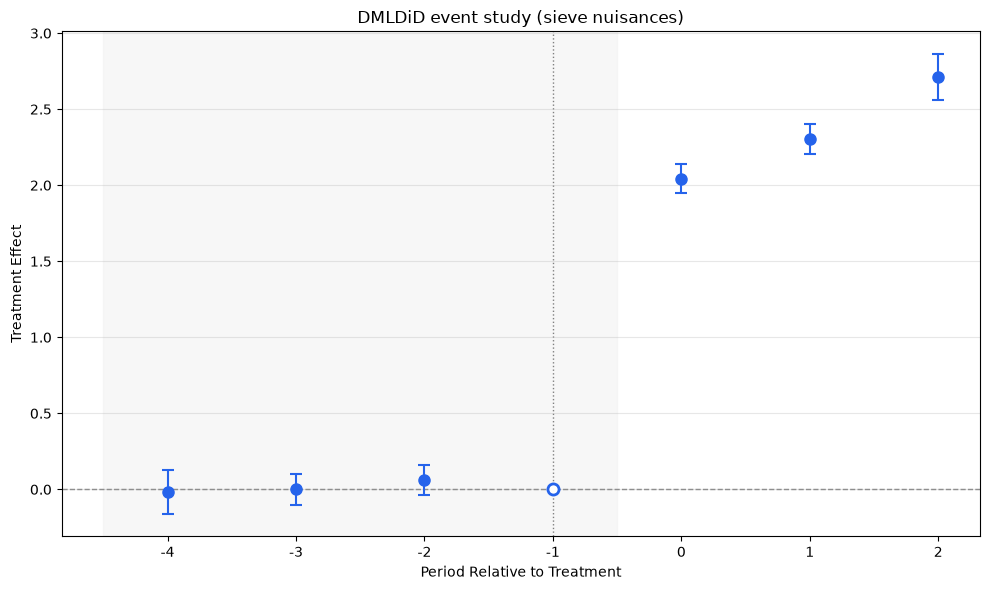

,event_time,att,se,conf_int_lower,conf_int_upper
0,-4,-0.0156,0.0731,-0.1588,0.1276
1,-3,-0.0004,0.0520,-0.1023,0.1014
2,-2,0.0618,0.0501,-0.0364,0.1599
3,-1,0.0000,NaN,NaN,NaN
4,0,2.0434,0.0492,1.9469,2.1399
5,1,2.3050,0.0496,2.2078,2.4022
6,2,2.7121,0.0760,2.5631,2.8611


In [8]:
es = res.aggregate("event_study")
fig = plot_event_study(es, title="DMLDiD event study (sieve nuisances)", show=False)
plt.show()
es.to_dataframe()[["event_time", "att", "se", "conf_int_lower", "conf_int_upper"]]


In [9]:
res.aggregate("group").to_dataframe()[["label", "att", "se",
                                       "conf_int_lower", "conf_int_upper"]]


,label,att,se,conf_int_lower,conf_int_upper
0,4,2.3758,0.0600,2.2581,2.4934
1,5,2.1418,0.0642,2.0160,2.2677


The event-study estimates track the true dynamic path $\tau(e) = 2.0 + 0.3e$
(**2.04, 2.30, 2.71** against true 2.0, 2.3, 2.6), pre-treatment effects sit near
zero, and the group effects order correctly (cohort 4, treated longer under a growing
effect, averages higher: **2.38** vs **2.14**).

**HonestDiD** (Rambachan & Roth 2023) bounds the effect under relaxations of
parallel trends: the relative-magnitude restriction bounds each post-treatment
*consecutive first difference* of the violation path by `M` times the largest
pre-treatment first difference (it does not cap violation *levels*, which can
accumulate over horizons). The event-study container
feeds it directly - this is why the fit used `base_period="universal"` (the
varying-base container warns: consecutive-period pre-treatment comparisons are not
the level deviations HonestDiD's $\delta$ bounds describe).


In [10]:
honest = compute_honest_did(es, method="relative_magnitude", M=1.0)
print(honest.summary())


               Honest DiD Sensitivity Analysis Results                
                       (Rambachan & Roth 2023)                        

Method:                        Relative Magnitudes (Delta^RM)
Target:                        Equal-weight avg over post horizons
Restriction parameter (M):     1.0000
CI method:                     FLCI

----------------------------------------------------------------------
              Original Estimate (under parallel trends)               
----------------------------------------------------------------------
Point estimate:                2.3535
Standard error:                0.0458

----------------------------------------------------------------------
               Robust Results (allowing for violations)               
----------------------------------------------------------------------
Identified set:                [2.2291, 2.4779]
95% Robust CI:                 [2.1393, 2.5677]

Effect robust to violations:   Yes

Pre horizons used

Even allowing each post-treatment *change* in the violation path to be as large
as the worst pre-treatment change (`M=1.0`), the robust CI **[2.14, 2.57]** stays
far from zero. One inheritance to keep in mind: this robust CI is built from the
section-3 fit, whose propensity model this DGP deliberately misspecifies - so
like every interval in this tutorial, read it as an API illustration rather than
a coverage guarantee (section 4's rate-condition caveat).

**Uniform (sup-t) bands** need a multiplier bootstrap: refit with `n_bootstrap=199`.
The overall ATT and every post-treatment cell are bit-identical to the analytical
fit - the bootstrap only replaces inference (the per-cell p-values become
`Boot. p` in `summary()`). This fit keeps the default `base_period="varying"`,
so the *pre-treatment* event-study rows below differ from section 6's
universal-base rows (a different comparison regime, not a bootstrap effect): a universal-base fit materializes zero-effect
reference cells whose bootstrap SE is undefined by construction (the fit would warn),
and this fit does not feed HonestDiD. `cband=True` (the default) emits the sup-t
band on the post-fit event-study replay - the band designed to cover the *entire*
dynamic path at 95%, not each point separately (nominal coverage, under the rate
conditions this DGP deliberately violates - the section-4 caveat applies here too).


In [11]:
res_boot = DMLDiD(outcome_learner="sieve", n_folds=5, seed=42,
                  n_bootstrap=199, cband=True).fit(df, **fit_kw)
print(f"analytical ATT {res.overall_att:.4f} | bootstrap ATT {res_boot.overall_att:.4f}")
res_boot.aggregate("event_study").to_dataframe()[
    ["event_time", "att", "conf_int_lower", "conf_int_upper",
     "cband_lower", "cband_upper"]]


analytical ATT 2.2804 | bootstrap ATT 2.2804


,event_time,att,conf_int_lower,conf_int_upper,cband_lower,cband_upper
0,-3,0.0092,-0.1385,0.1567,-0.1968,0.2152
1,-2,0.0624,-0.0356,0.1735,-0.0785,0.2033
2,-1,-0.0582,-0.1560,0.0344,-0.1947,0.0784
3,0,2.0434,1.9607,2.1187,1.9245,2.1622
4,1,2.3050,2.2239,2.4042,2.1810,2.4290
5,2,2.7121,2.5550,2.8304,2.5166,2.9075


## 7. Repeated Cross-Sections (`panel=False`)

Chang's Case 2 handles *repeated cross-sections* - fresh units sampled each wave
(think BRFSS, ACS, CPS supplements). Rows must be unique units (one observation per
row), and the estimator warns about the assumption you cannot test from data:
stationary cross-sectional sampling (Chang's Assumption 2.3 - each wave draws from
the same target population, so the composition of $(D, X)$ is stable across waves).
That warning is a caveat about the *lane*, not this dataset; it applies equally to
every `panel=False` fit in this section.


In [12]:
rng2 = np.random.default_rng(11)
n_rows = 5000
rx1 = rng2.normal(size=n_rows)
rx2 = rng2.normal(size=n_rows)
rscore = 0.9 * (rx1**2 - 1.0) + 0.7 * rx1 * rx2
rp = np.clip(1.0 / (1.0 + np.exp(-rscore)), 0.05, 0.60)
rtreated = rng2.uniform(size=n_rows) < rp
rearly = rng2.uniform(size=n_rows) < 0.5
rcohort = np.where(rtreated, np.where(rearly, 3, 4), 0)
rt = rng2.integers(1, 6, size=n_rows)  # waves 1..5
rf = 1.6 * (rx1**2 - 1.0) + 1.0 * rx1 * rx2
ry = (1.0 + 0.25 * rt + 0.5 * rx1 - 0.3 * rx2 + rf * (rt / 5.0)
      + rng2.normal(scale=0.6, size=n_rows))
rpost = (rcohort > 0) & (rt >= rcohort)
ry = ry + np.where(rpost, 2.0 + 0.3 * (rt - rcohort), 0.0)

# Survey structure for the closing example: 20 PSUs in 4 strata (5 each),
# mean-1 sampling weights.
rpsu = rng2.integers(0, 20, size=n_rows)
rw = rng2.uniform(0.5, 1.5, size=n_rows)
rcs = pd.DataFrame({
    "unit": np.arange(n_rows), "time": rt, "y": ry, "first_treat": rcohort,
    "x1": rx1, "x2": rx2,
    "psu": rpsu, "stratum": rpsu % 4, "w": rw / rw.mean(),
})

res_rcs = DMLDiD(outcome_learner="sieve", n_folds=5, seed=42,
                 panel=False).fit(rcs, **fit_kw)
print(f"RCS ATT: {res_rcs.overall_att:.4f} +/- {res_rcs.overall_se:.4f}")


RCS ATT: 2.4428 +/- 0.2373


/var/folders/bh/mzf05nq92hs6t7vn2ssvfhpr0000gn/T/ipykernel_41788/2521273073.py:27: UserWarning: panel=False uses Chang (2020) Case 2 repeated-cross-section scores, which assume stationary cross-sectional sampling (Assumption 2.3): each wave samples the SAME target population — conditional on the period, rows are i.i.d. draws from the distribution of (Y(0), D, X) (pre) or (Y(1), D, X) (post), so the composition of (D, X) is stable across waves while outcomes are the period-specific potential outcomes (trends and treatment effects are expected, not violations). This assumption is not data-checkable.
  res_rcs = DMLDiD(outcome_learner="sieve", n_folds=5, seed=42,


Repeated cross-sections are where complex survey data usually lives, and DMLDiD
accepts a `SurveyDesign` at `fit()` time (it is a `fit()` keyword, not a constructor
parameter). A declared design weights the moments and the learners (`sample_weight`),
makes cross-fitting folds **PSU-cohesive** (whole PSUs enter a fold together, so
within-cluster dependence cannot leak across the train/score split), and switches
inference to a design-based $t$ with $df = n_{PSU} - n_{strata}$:


In [13]:
res_svy = DMLDiD(outcome_learner="sieve", n_folds=5, seed=42, panel=False).fit(
    rcs, **fit_kw,
    survey_design=SurveyDesign(weights="w", strata="stratum", psu="psu"),
)
print(f"survey ATT: {res_svy.overall_att:.4f} +/- {res_svy.overall_se:.4f}")
print(f"design df:  {res_svy.survey_metadata.df_survey} "
      f"({res_svy.survey_metadata.n_psu} PSUs - "
      f"{res_svy.survey_metadata.n_strata} strata)")


survey ATT: 2.2886 +/- 0.1509
design df:  16 (20 PSUs - 4 strata)


/var/folders/bh/mzf05nq92hs6t7vn2ssvfhpr0000gn/T/ipykernel_41788/4091951892.py:1: UserWarning: panel=False uses Chang (2020) Case 2 repeated-cross-section scores, which assume stationary cross-sectional sampling (Assumption 2.3): each wave samples the SAME target population — conditional on the period, rows are i.i.d. draws from the distribution of (Y(0), D, X) (pre) or (Y(1), D, X) (post), so the composition of (D, X) is stable across waves while outcomes are the period-specific potential outcomes (trends and treatment effects are expected, not violations). This assumption is not data-checkable.
  res_svy = DMLDiD(outcome_learner="sieve", n_folds=5, seed=42, panel=False).fit(


Both fits bracket the design's true overall effect (about 2.24 under the same
$\tau(e) = 2.0 + 0.3e$): the unweighted fit gives **2.44 ± 0.24**, the
survey-weighted fit **2.29 ± 0.15** on **16** design degrees of freedom. Survey
tutorials proper - weight types, replicate designs, and the rest of the survey
toolkit - live in the *Survey-weighted DiD* tutorial.

## 8. Seeds and Reproducibility

`seed=` pins the cross-fitting fold draws, and therefore the *point estimates* - an
unseeded fit re-randomizes folds, so even the ATT moves between runs (`summary()`
prints the entropy an unseeded fit drew, so it can be reported after the fact). It
does **not** reach inside a custom learner: a stochastic learner needs its own
`random_state`-style seeding.


In [14]:
a = DMLDiD(outcome_learner="sieve", seed=1, base_period="universal").fit(df, **fit_kw)
b = DMLDiD(outcome_learner="sieve", seed=2, base_period="universal").fit(df, **fit_kw)
a2 = DMLDiD(outcome_learner="sieve", seed=1, base_period="universal").fit(df, **fit_kw)
print(f"seed=1:       {a.overall_att:.6f}")
print(f"seed=2:       {b.overall_att:.6f}   (different folds -> different estimate)")
print(f"seed=1 again: {a2.overall_att:.6f}   (bit-identical)")


seed=1:       2.271637
seed=2:       2.273391   (different folds -> different estimate)
seed=1 again: 2.271637   (bit-identical)


## Summary

| Situation | Reach for |
|-----------|-----------|
| Covariates with nonlinear / high-dimensional relationships to treatment or trends | `DMLDiD` |
| A logit + linear-OLS nuisance specification is plausible | `CallawaySantAnna` (fewer moving parts, replicate-weight support) |
| No covariates at all | `CallawaySantAnna` (DMLDiD requires covariates) |
| Repeated cross-sections, optionally with a complex survey design | `DMLDiD(panel=False)` + `survey_design=` |
| Conclusion must survive a learner swap | Refit with `outcome_learner=` alternatives (section 4; this is Baker et al.'s step 8) |

DMLDiD shares Callaway-Sant'Anna's cell architecture and post-fit aggregation
surface, so everything downstream - event studies, group effects, HonestDiD,
`DiagnosticReport`, `practitioner_next_steps` - works identically. The methodology
details (score functions, survey extension, trimming and skip conventions) are in
`docs/methodology/REGISTRY.md`.

**References**: Chang, N.-C. (2020). Double/debiased machine learning for
difference-in-differences models. *The Econometrics Journal*, 23(2), 177-191.
https://doi.org/10.1093/ectj/utaa001 | Rambachan, A. & Roth, J. (2023). A more
credible approach to parallel trends. *Review of Economic Studies*, 90(5).


## What next

Fitted results know their own follow-up work: `practitioner_next_steps()` returns
the Baker, Callaway, Cunningham, Goodman-Bacon & Sant'Anna (2025) practitioner
workflow steps as generic runnable templates - they carry the fit's design shape
(panel vs RCS, cluster, survey) but use placeholder column names and their own
seeds, so adapt them to your specification.


In [15]:
guidance = practitioner_next_steps(res)



Practitioner Guidance — DMLDiD (Chang 2020 double/debiased ML)
Baker et al. (2025) 8-Step Workflow

Recommended next steps (7 remaining):

  * [HIGH] Step 1: Define target parameter
    Why: State explicitly what causal effect you are estimating (ATT, ATT(g,t), weighted/unweighted) and what policy question it answers.
    >>> # What is the target parameter? ATT? Weighted or unweighted?

  * [HIGH] Step 2: State identification assumptions
    Why: Name the parallel trends variant you are invoking (unconditional, conditional, PT-GT-NYT, etc.), the no-anticipation assumption, and any overlap conditions.
    >>> # Which PT variant? No-anticipation? Overlap?

  * [HIGH] Step 3: Test parallel trends (event-study pre-periods)
    Why: For staggered designs, inspect event-study pre-period coefficients rather than the generic check_parallel_trends() which assumes a single binary treatment with universal pre-periods. Pre-treatment ATTs should be near zero. Use CS post-fit results.aggregate('eve